# Mechanical Systems with High Damping
### Saran Kaba (sk65556)

### The equation being used is
$\frac{dx}{dt}=-\frac{k}{c}+\frac{1}{c}F(t)$
#### in which
$damping-rate:\frac{k}{c}=5000s^-1$  
$external-force:F(t)=10sin(t) N$   
$initial-conditions:x(0)=1m$
#### The damping rate describes how fast the oscillations are being depressed, while the external force in the force being exterted on the system. The initial conditions shows the initial displacement to be at 1 meter. Having an extremely high damping rate while having a relatively slow force defines the system as a stiff equation. Understanding this system is valuable in machanical structures as it allows for the improvement of stability and function.

## Euler's Forward

In [114]:
def f(x, y):
    return -5000*y + 0.002*np.sin(x)

<ipython-input-114-f6543b765f1e>:2: RuntimeWarning: overflow encountered in double_scalars
  return -5000*y + 0.002*np.sin(x)
<ipython-input-115-9d308c9da407>:17: RuntimeWarning: invalid value encountered in double_scalars
  y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])


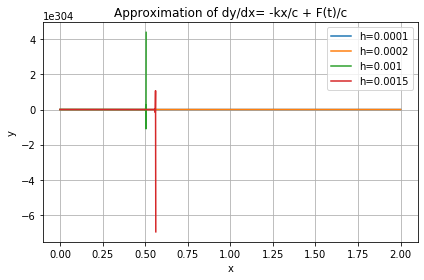

In [115]:
# Define parameters
hs = [0.0001,0.0002,0.001,0.0015]  # step size
x_start, x_end = 0, 2
num_steps = []

for h in hs:
    num_steps = int((x_end - x_start) / h)
    x_values=np.linspace(x_start, x_end, num_steps + 1)
    y_values=np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1  # y(0) = 1


    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
    
   
    # Plot the results
    plt.plot(x_values, y_values, label=f"h={h}")
plt.title('Approximation of dy/dx= -kx/c + F(t)/c')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## The stiffness ratio for this system is 5000
### The graph above shows how even small step sizes make it unstable, therefore an even smaller one is required due to the stiffness of the system. The step size required for stability is 0.0004, which is extremely small and would cause in overflow error because it would take 5,000 steps. This would cause and increased computational burden as it would take more time and energy to solve the equation. The solution is to use implicit methods. It is called implicit because rather than solving in terms of known values for n, it is solving in terms of unknown values to get n+1. These methods are stable for an infinite step size allowing a solution to require less steps taken and thus lightening the computational stress. The method being analyzed below is Euler's Backwards, which unlike its counterpart, Euler's Forward, it requires the first derivate of the equation (listed below as g').

## Euler's Backward

### g' = -5000

In [116]:
def fprime(y):
    return -5000
def analytical_solution(t):
    return np.exp(-5000*t)+4e-4*np.sin(t)-8e-8*np.cos(t)

# Newton-Raphson for single step with Backward Euler
def backward_euler_step(f, y, t, h, tol=1e-6, max_iter=20):
    total_iterations=0  #calculating the number of iterations per time step
    y_next = y  # Initial guess
    for _ in range(max_iter):
        total_iterations+=1
        g_val = y_next - y - h * f(t + h, y_next)
        g_prime_val = 1 - h * fprime(y_next)     
        if abs(g_prime_val) < tol:  # Avoid division by zero
            break
        y_new = y_next - g_val / g_prime_val
        if abs(y_new - y_next) < tol:
            return y_new,total_iterations  # Converged
        y_next = y_new
    return y_next,total_iterations

# Adaptive Backward Euler
def backward_euler_adaptive(f, y0, t0, tf, h_init, tol=1e-6, max_iter=20):
    t_values = [t0]
    y_values = [y0]
    h = h_init
    t = t0
    y = y0
    tot_it_f=[0]
    sol_error=[np.abs(analytical_solution(t0)-y0)]
    while t < tf:
        if t + h > tf:  # Adjust step size to not overshoot
            h = tf - t
        # Single step with h
        y_full,t_it_f = backward_euler_step(f, y, t, h, tol, max_iter)
        # Two half-steps with h/2
        h_half = h / 2
        y_half_1,t_it_1 = backward_euler_step(f, y, t, h_half, tol, max_iter)
        y_half_2,t_it_2 = backward_euler_step(f, y_half_1, t + h_half, h_half, tol, max_iter)
        # Error estimation
        error = abs(y_full - y_half_2)
        # Adjust step size
        if error > tol:
            h /= 2  # Decrease step size
            continue  # Retry the step with smaller h
        elif error < tol / 2:
            h *= 2  # Increase step size for efficiency
        # Accept the step
        t += h
        y = y_half_2
        t_values.append(t)
        y_values.append(y)
        tot_it_f.append(t_it_f+t_it_1+t_it_2)
        #Calculating the error
        sol_error.append(np.abs(analytical_solution(t)-y))

    return np.array(t_values), np.array(y_values),np.array(tot_it_f),np.array(sol_error)



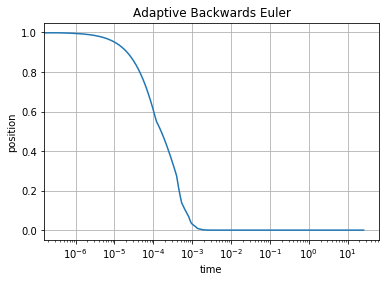

In [117]:
y=1
t0=0
tf=20
h=0.1

t_values,y_values,total_iterations,error=backward_euler_adaptive(f, y, t0, tf, h, tol=1e-6, max_iter=20)

plt.figure()
plt.plot(t_values,y_values)
plt.xlabel('time')
plt.ylabel('position')
plt.xscale('log')
plt.grid(True)
plt.title('Adaptive Backwards Euler')
plt.show()

## Stability Analysis and Comparison

### The maximum step size required for stability when solving using Euler's Forward is 0.0004. Backwards Euler does not have a max step size required for stability, although too high of an h value will lead to inaccuracies.


| Step Size | Euler's Forward Stability | Euler's Backward Stability |
|----------|----------|----------|
| 0.0001 | Stable | Stable |
| 0.0002 | Stable | Stable |
| 0.0003 | Stable | Stable |
| 0.0004 | Stable | Stable |
| 0.0005 | Unstable | Stable |
| 1.0 | Unstable | Stable |

### As represented in the table, Euler's Forward requires a  miniscule step size in order to reach stability. This comes at a computational disadvantage as it not only increases the time needed for finding the solution, but it comes at the cost of resources and finances.

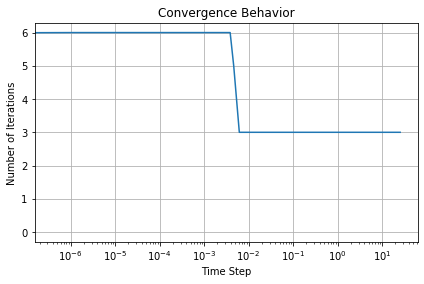

In [118]:
plt.figure()
plt.plot(t_values,total_iterations)
plt.title('Convergence Behavior')
plt.xlabel('Time Step')
plt.ylabel('Number of Iterations')
plt.tight_layout()
plt.xscale('log')
plt.grid(True)
plt.show()

### The covergence behavior shows with an increased step, decreased step size, comes a decrease in the number of iterations before convergence. This means that although the problem is being run more times, the more times it runs the less iterations it requires, although it still comes at a higher computational cost.
### This brings it into the coversation of finding the right balance between having a n accurate solution and the least steps taken possible. While it can be easy to choose an extremely small step size for the sake of finding generating an answer as close to the analytical solution as possible, it is important to take into account the strain it causes computationally. An error analysis may be useful in finding the right step size:

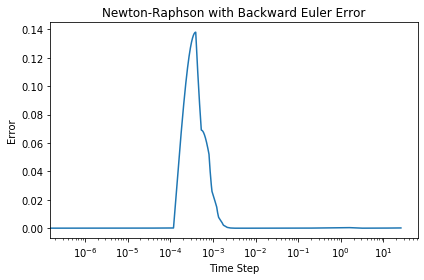

In [119]:
plt.figure()
plt.plot(t_values,error)
plt.xlabel('Time Step')
plt.ylabel('Error')
plt.title('Newton-Raphson with Backward Euler Error')
plt.xscale('log')
plt.tight_layout()
plt.show()

### From the data gathered, it can be concluded that the most efficient step size would be found between 0.001 and 0.01. In this range the error is low while also maintaining a low number of iterations used.

## Conclusion

### Overall, the implicit method of Euler's Backward showed its superiority over the explicit Euler's Forward, by showing it resistance to low step sizes and its ability to use high step sizes with little calculation error. This is beneficial in lowering the computational and financial burden as it demonstrates an increased efficiency. Euler's Forward would be useful when the limits of the system do not require a small stp size as it would then have a computational advantage over the implicit method. It would also require less of a setup on the part of the programmer and no derivative calculation. While Euler's Backward could use any step size, the right one needed to be used by finding the right crossroads between computational stress and accuracy. The suitable range was found to be between 0.001 and 0.01.